# The heart of the Elastic Stack {background-color="white" background-image="images/heart.jpeg" background-size="50%" background-opacity="1" background-position="top"}

## What is Elasticsearch?


:::: {.columns}

::: {.fragment .column width="50%"}
![](https://static-www.elastic.co/v3/assets/bltefdd0b53724fa2ce/blt36f2da8d650732a0/5d0823c3d8ff351753cbc99f/logo-elasticsearch-32-color.svg)

Elasticsearch is

- an open source distributed
- RESTful search and analytics engine
- built on Apache Lucene
- scalable data store
- optimized for full-text search
- capable of handling structured and unstructured data
::: 

::: {.fragment .column width="50%"}
Key capabilities:

- **Lightning-fast search** across massive datasets
- **Real-time indexing** and search
- **Distributed architecture** for horizontal scalability
- **RESTful API** for easy integration
- **Powerful aggregations** for data analytics
:::
::::



## Elastic{background-color="#ffffffff" background-image="https://static-www.elastic.co/v3/assets/bltefdd0b53724fa2ce/blt38bc64a0dc522c22/6851d0a22d38bb50549d7540/illustration-hero-platform-search-security-observability-2x_v2.png" background-size="100%" background-opacity="1"}

<https://elastic.co>

## Origin

:::: {.columns}

::: {.fragment .column width="35%"}
It started with a recipe app...

![](https://i.imgflip.com/41pcjq.jpg)
[NicsMeme](https://imgflip.com/i/41pcjq)
[Tears and Sweet](https://dictionary.cambridge.org/dictionary/english/blood-sweat-and-tears)
::: 

::: {.fragment .column width="65%"}
- In a London apartment, Shay Banon was looking for a job while his wife attended cooking school at Le Cordon Bleu. In his spare time, he started building a search engine for her growing list of recipes.
- His first iteration was called Compass. The second was Elasticsearch (with [Apache Lucene](https://lucene.apache.org/) under the hood). He open sourced Elasticsearch, created the #elasticsearch IRC channel, and waited for users to appear.
- The response was impressive. Users took to it naturally and easily. Adoption went through the roof, a community started to form, and people noticed — namely Steven Schuurman, Uri Boness, and Simon Willnauer. Together, they founded a search company.
:::
::::


## Leader in search engine

:::: {.columns}


  
::: {.fragment .column width="50%"}

- 2nd place in the search engine category <https://db-engines.com/en/ranking/search+engine>
- 10th in the global list <https://db-engines.com/en/ranking>

::: 

::: {.fragment .column width="50%"}
![](https://images.contentstack.io/v3/assets/bltefdd0b53724fa2ce/bltb86451a4b99298bb/685aa4f502c363f4d74a67cc/elastic-forrester-wave-2025-security-analytics-platforms.png)
:::
::::


## Let's see the website!
<https://www.elastic.co/elasticsearch/>

## Setting Up Elasticsearch

We'll run Elasticsearch in Docker for easy setup and isolation.

<https://www.elastic.co/guide/en/elasticsearch/reference/current/docker.html#docker>

::: {.fragment}
```bash
docker run --name es01 --net tap -p 9200:9200 -it -m 1GB docker.elastic.co/elasticsearch/elasticsearch:9.2.2
```
:::

::: {.fragment}
**Important steps:**


1. Check the logs to find the auto-generated password for the `elastic` user

2. Access the REST API at <https://localhost:9200/>

3. Accept the self-signed SSL certificate warning (development only)

:::

## Interacting with Elasticsearch via REST API

Elasticsearch exposes all functionality through a RESTful HTTP API. We'll use Python's `requests` library to interact with it.

<https://requests.readthedocs.io/en/master/>

In [14]:
# Install
!pip install requests

In [15]:
# Import
import requests
from requests.auth import HTTPBasicAuth

## Configuring Authentication

Elasticsearch 8+ requires authentication by default for security. We'll use HTTP Basic Authentication with the `elastic` superuser.

In [16]:

# Set your Elasticsearch credentials
# Replace 'elastic' and 'your_password' with your actual credentials
ES_USER = 'elastic'
ES_PASSWORD = 'l4X2_EUe*GpbLKYhBEKt'  # Check Docker logs for the generated password
auth = HTTPBasicAuth(ES_USER, ES_PASSWORD)

## Indexing Documents

In Elasticsearch, data is stored as JSON documents in **indices** (similar to tables in relational databases). Let's add our first document.

In [17]:
# Single record
doc = """{
  "name": "Salvo Nicotra"
}"""

url="https://localhost:9200/tap/_doc/1"
headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url, data=doc, headers=headers, auth=auth, verify=False)
r.status_code

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


200

In [18]:
r.text

'{"_index":"tap","_id":"1","_version":2,"result":"updated","_shards":{"total":2,"successful":1,"failed":0},"_seq_no":1,"_primary_term":1}'

In [19]:
# And get it back
url="https://localhost:9200/tap/_doc/1"
r = requests.get(url, auth=auth, verify=False)
r.json()


/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'_index': 'tap',
 '_id': '1',
 '_version': 2,
 '_seq_no': 1,
 '_primary_term': 1,
 'found': True,
 '_source': {'name': 'Salvo Nicotra'}}

## Bulk Indexing

For production use, the Bulk API is essential for indexing large datasets efficiently. Batches of 1000-5000 documents are typically optimal.

```json
{
  "account_number": 1,
  "balance": 39225,
  "firstname": "Amber",
  "lastname": "Duke",
  "age": 32,
  "gender": "M",
  "address": "880 Holmes Lane",
  "employer": "Pyrami",
  "email": "amberduke@pyrami.com",
  "city": "Brogan",
  "state": "IL"
}
```
[Accounts.json](https://github.com/linuxacademy/content-elasticsearch-deep-dive/blob/master/sample_data/accounts.json)

## Sample Dataset

We'll use a sample dataset of 1000 bank accounts to demonstrate Elasticsearch's search and aggregation capabilities.

In [21]:
%%bash
wget https://raw.githubusercontent.com/linuxacademy/content-elasticsearch-deep-dive/master/sample_data/accounts.json

--2025-12-10 22:39:31--  https://raw.githubusercontent.com/linuxacademy/content-elasticsearch-deep-dive/master/sample_data/accounts.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 244848 (239K) [text/plain]
Saving to: ‘accounts.json.1’

     0K .......... .......... .......... .......... .......... 20%  529K 0s
    50K .......... .......... .......... .......... .......... 41% 1.41M 0s
   100K .......... .......... .......... .......... .......... 62%  783K 0s
   150K .......... .......... .......... .......... .......... 83% 1.62M 0s
   200K .......... .......... .......... .........            100% 1.42M=0.3s

2025-12-10 22:39:32 (956 KB/s) - ‘accounts.json.1’ saved [244848/244848]



In [25]:
!curl -k -u elastic:l4X2_EUe*GpbLKYhBEKt -H "Content-Type: application/json" -XPOST "https://localhost:9200/bank/_bulk?pretty&refresh" --data-binary "@accounts.json"

{
  "errors" : false,
  "took" : 1200,
  "items" : [
    {
      "index" : {
        "_index" : "bank",
        "_id" : "1",
        "_version" : 1,
        "result" : "created",
        "forced_refresh" : true,
        "_shards" : {
          "total" : 2,
          "successful" : 1,
          "failed" : 0
        },
        "_seq_no" : 0,
        "_primary_term" : 1,
        "status" : 201
      }
    },
    {
      "index" : {
        "_index" : "bank",
        "_id" : "6",
        "_version" : 1,
        "result" : "created",
        "forced_refresh" : true,
        "_shards" : {
          "total" : 2,
          "successful" : 1,
          "failed" : 0
        },
        "_seq_no" : 1,
        "_primary_term" : 1,
        "status" : 201
      }
    },
    {
      "index" : {
        "_index" : "bank",
        "_id" : "13",
        "_version" : 1,
        "result" : "created",
        "forced_refresh" : true,
        "_shards" : {
          "total" : 2,
          "successful" : 1,
  

In [26]:
# Index Status
r = requests.get('https://localhost:9200/_cat/indices?v', auth=auth, verify=False)
r.text

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


'health status index uuid                   pri rep docs.count docs.deleted store.size pri.store.size dataset.size\nyellow open   bank  9lbCKqLxR_i8JS0mS3j4Lg   1   1       1000            0      372kb          372kb        372kb\nyellow open   tap   AOHhOk8OTW-yQgAZh30QTw   1   1          1            1     10.6kb         10.6kb       10.6kb\n'

## Searching with Query DSL

Elasticsearch provides a rich **Query DSL (Domain Specific Language)** for expressing complex search queries in JSON format.

Every search is sent to the `_search` endpoint. Let's start with a simple query that retrieves all documents, sorted by balance:

In [27]:
data = """{
  "query": { "match_all": {} },
  "sort": [
    { "balance": "desc" }
  ]
}"""

url="https://localhost:9200/bank/_search?pretty"

headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url,data=data, auth=auth, verify=False,  headers=headers)

r.json()

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'took': 309,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 1000, 'relation': 'eq'},
  'max_score': None,
  'hits': [{'_index': 'bank',
    '_id': '248',
    '_score': None,
    '_source': {'account_number': 248,
     'balance': 49989,
     'firstname': 'West',
     'lastname': 'England',
     'age': 36,
     'gender': 'M',
     'address': '717 Hendrickson Place',
     'employer': 'Obliq',
     'email': 'westengland@obliq.com',
     'city': 'Maury',
     'state': 'WA'},
    'sort': [49989]},
   {'_index': 'bank',
    '_id': '854',
    '_score': None,
    '_source': {'account_number': 854,
     'balance': 49795,
     'firstname': 'Jimenez',
     'lastname': 'Barry',
     'age': 25,
     'gender': 'F',
     'address': '603 Cooper Street',
     'employer': 'Verton',
     'email': 'jimenezbarry@verton.com',
     'city': 'Moscow',
     'state': 'AL'},
    'sort': [49795]},
   {'_index': 'bank',
    '_id': '240',
    '

## Full-Text Search

The `match` query performs full-text search with analysis (tokenization, stemming, etc.). It finds documents where the field contains any of the search terms:

In [28]:
data = """{
  "query": { "match": { "address": "Mill Lane" } }
}"""

url="https://localhost:9200/bank/_search?pretty"

headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url,data=data, auth=auth, verify=False,  headers=headers)
r.json()

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'took': 164,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 19, 'relation': 'eq'},
  'max_score': 9.507477,
  'hits': [{'_index': 'bank',
    '_id': '136',
    '_score': 9.507477,
    '_source': {'account_number': 136,
     'balance': 45801,
     'firstname': 'Winnie',
     'lastname': 'Holland',
     'age': 38,
     'gender': 'M',
     'address': '198 Mill Lane',
     'employer': 'Neteria',
     'email': 'winnieholland@neteria.com',
     'city': 'Urie',
     'state': 'IL'}},
   {'_index': 'bank',
    '_id': '970',
    '_score': 5.4032025,
    '_source': {'account_number': 970,
     'balance': 19648,
     'firstname': 'Forbes',
     'lastname': 'Wallace',
     'age': 28,
     'gender': 'M',
     'address': '990 Mill Road',
     'employer': 'Pheast',
     'email': 'forbeswallace@pheast.com',
     'city': 'Lopezo',
     'state': 'AK'}},
   {'_index': 'bank',
    '_id': '345',
    '_score': 5.4032025,
    '_source':

## Phrase Search

The `match_phrase` query matches the exact phrase in the specified order, useful when word order matters:

In [29]:
data = """{
  "query": { "match_phrase": { "address": "mill Lane" } }
}"""

url="https://localhost:9200/bank/_search?pretty"

headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url,data=data, auth=auth, verify=False,  headers=headers)
r.json()

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'took': 34,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 1, 'relation': 'eq'},
  'max_score': 9.507477,
  'hits': [{'_index': 'bank',
    '_id': '136',
    '_score': 9.507477,
    '_source': {'account_number': 136,
     'balance': 45801,
     'firstname': 'Winnie',
     'lastname': 'Holland',
     'age': 38,
     'gender': 'M',
     'address': '198 Mill Lane',
     'employer': 'Neteria',
     'email': 'winnieholland@neteria.com',
     'city': 'Urie',
     'state': 'IL'}}]}}

## Boolean Queries

The `bool` query combines multiple query clauses with boolean logic:

- **must**: Clauses that must match (AND logic)

- **should**: Clauses that should match (OR logic, affects scoring)Example: Find female customers who are 40 years old, excluding those from Idaho:

- **must_not**: Clauses that must not match (NOT logic)
- **filter**: Must match but doesn't affect scoring (for exact matches)

In [30]:
data = """{

  "query": {
    "bool": {
      "must": [
        { "match": { "age": "40" } },
        { "match": { "gender": "F" } }
      ],
      "must_not": [
        { "match": { "state": "ID" } }
      ]
    }
  }
}"""

url="https://localhost:9200/bank/_search?pretty"

headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url,data=data, auth=auth, verify=False,  headers=headers)
r.json()

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'took': 29,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 20, 'relation': 'eq'},
  'max_score': 1.707232,
  'hits': [{'_index': 'bank',
    '_id': '474',
    '_score': 1.707232,
    '_source': {'account_number': 474,
     'balance': 35896,
     'firstname': 'Obrien',
     'lastname': 'Walton',
     'age': 40,
     'gender': 'F',
     'address': '192 Ide Court',
     'employer': 'Suremax',
     'email': 'obrienwalton@suremax.com',
     'city': 'Crucible',
     'state': 'UT'}},
   {'_index': 'bank',
    '_id': '878',
    '_score': 1.707232,
    '_source': {'account_number': 878,
     'balance': 49159,
     'firstname': 'Battle',
     'lastname': 'Blackburn',
     'age': 40,
     'gender': 'F',
     'address': '234 Hendrix Street',
     'employer': 'Zilphur',
     'email': 'battleblackburn@zilphur.com',
     'city': 'Wanamie',
     'state': 'PA'}},
   {'_index': 'bank',
    '_id': '885',
    '_score': 1.707232,
   

## Filtering and Relevance Scoring

**Understanding Scoring:**

- `must` and `should` clauses contribute to the **relevance score** (_score)
- Documents are ranked by how well they match your query
- Higher scores = better matches

**Filters for Exact Matching:**

- Filters don't affect scoring (faster and cacheable)

- Use filters for exact matches: ranges, terms, exists, etc.Example: Find all accounts with balance between $20,000 and $30,000:

- The `filter` clause in a `bool` query is perfect for structured data

In [31]:
data = """{
  "query": {
    "bool": {
      "must": { "match_all": {} },
      "filter": {
        "range": {
          "balance": {
            "gte": 20000,
            "lte": 30000
          }
        }
      }
    }
  }
}"""

url="https://localhost:9200/bank/_search?pretty"

headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url,data=data, auth=auth, verify=False,  headers=headers)
r.json()

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'took': 27,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 217, 'relation': 'eq'},
  'max_score': 1.0,
  'hits': [{'_index': 'bank',
    '_id': '49',
    '_score': 1.0,
    '_source': {'account_number': 49,
     'balance': 29104,
     'firstname': 'Fulton',
     'lastname': 'Holt',
     'age': 23,
     'gender': 'F',
     'address': '451 Humboldt Street',
     'employer': 'Anocha',
     'email': 'fultonholt@anocha.com',
     'city': 'Sunriver',
     'state': 'RI'}},
   {'_index': 'bank',
    '_id': '102',
    '_score': 1.0,
    '_source': {'account_number': 102,
     'balance': 29712,
     'firstname': 'Dena',
     'lastname': 'Olson',
     'age': 27,
     'gender': 'F',
     'address': '759 Newkirk Avenue',
     'employer': 'Hinway',
     'email': 'denaolson@hinway.com',
     'city': 'Choctaw',
     'state': 'NJ'}},
   {'_index': 'bank',
    '_id': '133',
    '_score': 1.0,
    '_source': {'account_number': 133,

## Aggregations: Analytics at Scale

Aggregations allow you to analyze and summarize your data:


- **Metrics**: Calculate statistics (avg, min, max, sum, etc.)Example: Group accounts by state and count how many accounts each state has:

- **Buckets**: Group documents (terms, ranges, histograms, etc.)

- **Pipeline**: Aggregate on aggregation resultsYou can combine search queries with aggregations in a single request for powerful analytics.


In [32]:
data = """{
  "aggs": {
    "group_by_state": {
      "terms": {
        "field": "state.keyword"
      }
    }
  }
}"""

url="https://localhost:9200/bank/_search?pretty"

headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url,data=data, auth=auth, verify=False,  headers=headers)
r.json()

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'took': 214,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 1000, 'relation': 'eq'},
  'max_score': 1.0,
  'hits': [{'_index': 'bank',
    '_id': '1',
    '_score': 1.0,
    '_source': {'account_number': 1,
     'balance': 39225,
     'firstname': 'Amber',
     'lastname': 'Duke',
     'age': 32,
     'gender': 'M',
     'address': '880 Holmes Lane',
     'employer': 'Pyrami',
     'email': 'amberduke@pyrami.com',
     'city': 'Brogan',
     'state': 'IL'}},
   {'_index': 'bank',
    '_id': '6',
    '_score': 1.0,
    '_source': {'account_number': 6,
     'balance': 5686,
     'firstname': 'Hattie',
     'lastname': 'Bond',
     'age': 36,
     'gender': 'M',
     'address': '671 Bristol Street',
     'employer': 'Netagy',
     'email': 'hattiebond@netagy.com',
     'city': 'Dante',
     'state': 'TN'}},
   {'_index': 'bank',
    '_id': '13',
    '_score': 1.0,
    '_source': {'account_number': 13,
     'balance'

### Nested Aggregations

Aggregations can be nested to create sophisticated analytics. Here we nest an `avg` metric inside a `terms` bucket aggregation:

In [33]:
data = """{
  "size": 0,
  "aggs": {
    "group_by_state": {
      "terms": {
        "field": "state.keyword"
      },
      "aggs": {
        "average_balance": {
          "avg": {
            "field": "balance"
          }
        }
      }
    }
  }
}"""

url="https://localhost:9200/bank/_search?pretty"

headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url,data=data, auth=auth, verify=False,  headers=headers)
r.json()

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'took': 97,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 1000, 'relation': 'eq'},
  'max_score': None,
  'hits': []},
 'aggregations': {'group_by_state': {'doc_count_error_upper_bound': 0,
   'sum_other_doc_count': 743,
   'buckets': [{'key': 'TX',
     'doc_count': 30,
     'average_balance': {'value': 26073.3}},
    {'key': 'MD',
     'doc_count': 28,
     'average_balance': {'value': 26161.535714285714}},
    {'key': 'ID',
     'doc_count': 27,
     'average_balance': {'value': 24368.777777777777}},
    {'key': 'AL', 'doc_count': 25, 'average_balance': {'value': 25739.56}},
    {'key': 'ME', 'doc_count': 25, 'average_balance': {'value': 21663.0}},
    {'key': 'TN', 'doc_count': 25, 'average_balance': {'value': 28365.4}},
    {'key': 'WY', 'doc_count': 25, 'average_balance': {'value': 21731.52}},
    {'key': 'DC',
     'doc_count': 24,
     'average_balance': {'value': 23180.583333333332}},
    {'key': 'MA',


### Sorting Aggregation Buckets

By default, term aggregations are sorted by document count. You can sort by nested aggregation results instead:

In [34]:
data = """{
  "size": 0,
  "aggs": {
    "group_by_state": {
      "terms": {
        "field": "state.keyword",
        "order": {
          "average_balance": "desc"
        }
      },
      "aggs": {
        "average_balance": {
          "avg": {
            "field": "balance"
          }
        }
      }
    }
  }
}"""

url="https://localhost:9200/bank/_search?pretty"

headers = {'Content-type': 'application/json', 'Accept': 'text/plain'}

r = requests.post(url,data=data, auth=auth, verify=False,  headers=headers)
r.json()

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


{'took': 68,
 'timed_out': False,
 '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0},
 'hits': {'total': {'value': 1000, 'relation': 'eq'},
  'max_score': None,
  'hits': []},
 'aggregations': {'group_by_state': {'doc_count_error_upper_bound': -1,
   'sum_other_doc_count': 827,
   'buckets': [{'key': 'CO',
     'doc_count': 14,
     'average_balance': {'value': 32460.35714285714}},
    {'key': 'NE', 'doc_count': 16, 'average_balance': {'value': 32041.5625}},
    {'key': 'AZ',
     'doc_count': 14,
     'average_balance': {'value': 31634.785714285714}},
    {'key': 'MT',
     'doc_count': 17,
     'average_balance': {'value': 31147.41176470588}},
    {'key': 'VA', 'doc_count': 16, 'average_balance': {'value': 30600.0625}},
    {'key': 'GA', 'doc_count': 19, 'average_balance': {'value': 30089.0}},
    {'key': 'MA',
     'doc_count': 24,
     'average_balance': {'value': 29600.333333333332}},
    {'key': 'IL',
     'doc_count': 22,
     'average_balance': {'value': 29489

## Using the Python Client


While the REST API works well, the official Python client provides a more convenient, Pythonic interface with:https://elasticsearch-py.readthedocs.io/en/stable/



- Automatic request serialization/deserialization- Type hints for better IDE support

- Connection pooling and retry logic- Better error handling

### Install

In [35]:
!pip install elasticsearch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.5/960.5 kB 1.3 MB/s eta 0:00:000:00:010:00:01:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 2.3 MB/s eta 0:00:00


### Import

In [36]:
from elasticsearch import Elasticsearch

In [38]:
# by default we connect to localhost:9200
es = Elasticsearch("https://localhost:9200", basic_auth=(ES_USER, ES_PASSWORD), verify_certs=False)
es

<Elasticsearch(['https://localhost:9200'])>

In [39]:
es.get(index="bank", id=1)

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'_index': 'bank', '_id': '1', '_version': 1, '_seq_no': 0, '_primary_term': 1, 'found': True, '_source': {'account_number': 1, 'balance': 39225, 'firstname': 'Amber', 'lastname': 'Duke', 'age': 32, 'gender': 'M', 'address': '880 Holmes Lane', 'employer': 'Pyrami', 'email': 'amberduke@pyrami.com', 'city': 'Brogan', 'state': 'IL'}})

In [40]:
# New in ES 8
es.search(index="bank", query={"match": {'firstname':'Aurelia'}})

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'took': 17, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 1, 'relation': 'eq'}, 'max_score': 6.5032897, 'hits': [{'_index': 'bank', '_id': '44', '_score': 6.5032897, '_source': {'account_number': 44, 'balance': 34487, 'firstname': 'Aurelia', 'lastname': 'Harding', 'age': 37, 'gender': 'M', 'address': '502 Baycliff Terrace', 'employer': 'Orbalix', 'email': 'aureliaharding@orbalix.com', 'city': 'Yardville', 'state': 'DE'}}]}})

## Advanced Search Techniques

Let's explore additional query types for sophisticated search scenarios.

### Fuzzy Search

Fuzzy queries handle typos and spelling variations using **Levenshtein distance** (edit distance). Perfect for improving user experience:

In [42]:
# Find names similar to "Aurlia" (missing an 'e')
es.search(index="bank", query={
    "fuzzy": {
        "firstname": {
            "value": "Aurlia",
            "fuzziness": "AUTO"
        }
    }
})

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'took': 161, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 1, 'relation': 'eq'}, 'max_score': 4.335526, 'hits': [{'_index': 'bank', '_id': '44', '_score': 4.335526, '_source': {'account_number': 44, 'balance': 34487, 'firstname': 'Aurelia', 'lastname': 'Harding', 'age': 37, 'gender': 'M', 'address': '502 Baycliff Terrace', 'employer': 'Orbalix', 'email': 'aureliaharding@orbalix.com', 'city': 'Yardville', 'state': 'DE'}}]}})

## Working with Search Results

The Elasticsearch Python client returns `ObjectApiResponse` objects. Let's explore different ways to extract and format the data for analysis:

#### Extract Just the Source Documents

In [43]:
response = es.search(index="bank", query={"match": {'firstname':'Aurelia'}})

# Extract just the documents
for hit in response['hits']['hits']:
    print(hit['_source'])

{'account_number': 44, 'balance': 34487, 'firstname': 'Aurelia', 'lastname': 'Harding', 'age': 37, 'gender': 'M', 'address': '502 Baycliff Terrace', 'employer': 'Orbalix', 'email': 'aureliaharding@orbalix.com', 'city': 'Yardville', 'state': 'DE'}


/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


#### Pretty Print with JSON

In [44]:
import json

response = es.search(index="bank", query={"match": {'firstname':'Aurelia'}})

# Pretty print the entire response
print(json.dumps(response.body, indent=2))

{
  "took": 12,
  "timed_out": false,
  "_shards": {
    "total": 1,
    "successful": 1,
    "skipped": 0,
    "failed": 0
  },
  "hits": {
    "total": {
      "value": 1,
      "relation": "eq"
    },
    "max_score": 6.5032897,
    "hits": [
      {
        "_index": "bank",
        "_id": "44",
        "_score": 6.5032897,
        "_source": {
          "account_number": 44,
          "balance": 34487,
          "firstname": "Aurelia",
          "lastname": "Harding",
          "age": 37,
          "gender": "M",
          "address": "502 Baycliff Terrace",
          "employer": "Orbalix",
          "email": "aureliaharding@orbalix.com",
          "city": "Yardville",
          "state": "DE"
        }
      }
    ]
  }
}


/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


#### Display as Pandas DataFrame

In [46]:
!pip install pandas

  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)


In [47]:
import pandas as pd

response = es.search(index="bank", query={"match_all": {}}, size=10)

# Convert to DataFrame
hits = [hit['_source'] for hit in response['hits']['hits']]
df = pd.DataFrame(hits)
df

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,account_number,balance,firstname,lastname,age,gender,address,employer,email,city,state
0,1,39225,Amber,Duke,32,M,880 Holmes Lane,Pyrami,amberduke@pyrami.com,Brogan,IL
1,6,5686,Hattie,Bond,36,M,671 Bristol Street,Netagy,hattiebond@netagy.com,Dante,TN
2,13,32838,Nanette,Bates,28,F,789 Madison Street,Quility,nanettebates@quility.com,Nogal,VA
3,18,4180,Dale,Adams,33,M,467 Hutchinson Court,Boink,daleadams@boink.com,Orick,MD
4,20,16418,Elinor,Ratliff,36,M,282 Kings Place,Scentric,elinorratliff@scentric.com,Ribera,WA
5,25,40540,Virginia,Ayala,39,F,171 Putnam Avenue,Filodyne,virginiaayala@filodyne.com,Nicholson,PA
6,32,48086,Dillard,Mcpherson,34,F,702 Quentin Street,Quailcom,dillardmcpherson@quailcom.com,Veguita,IN
7,37,18612,Mcgee,Mooney,39,M,826 Fillmore Place,Reversus,mcgeemooney@reversus.com,Tooleville,OK
8,44,34487,Aurelia,Harding,37,M,502 Baycliff Terrace,Orbalix,aureliaharding@orbalix.com,Yardville,DE
9,49,29104,Fulton,Holt,23,F,451 Humboldt Street,Anocha,fultonholt@anocha.com,Sunriver,RI


#### Custom Formatted Output

In [48]:
response = es.search(index="bank", query={"match": {'state':'CA'}}, size=5)

print(f"Found {response['hits']['total']['value']} results\n")
print("=" * 80)

for hit in response['hits']['hits']:
    doc = hit['_source']
    print(f"\nAccount #{doc['account_number']}")
    print(f"Name: {doc['firstname']} {doc['lastname']}")
    print(f"Balance: ${doc['balance']:,}")
    print(f"Address: {doc['address']}, {doc['city']}, {doc['state']}")
    print(f"Score: {hit['_score']}")
    print("-" * 80)

Found 17 results


Account #68
Name: Hall Key
Balance: $44,214
Address: 927 Bay Parkway, Shawmut, CA
Score: 4.046554
--------------------------------------------------------------------------------

Account #328
Name: Good Campbell
Balance: $12,523
Address: 438 Hicks Street, Marion, CA
Score: 4.046554
--------------------------------------------------------------------------------

Account #967
Name: Carrie Huffman
Balance: $19,161
Address: 240 Sands Street, Leroy, CA
Score: 4.046554
--------------------------------------------------------------------------------

Account #413
Name: Pugh Hamilton
Balance: $15,631
Address: 124 Euclid Avenue, Beaulieu, CA
Score: 4.046554
--------------------------------------------------------------------------------

Account #437
Name: Rosales Marquez
Balance: $41,225
Address: 873 Ryerson Street, Allendale, CA
Score: 4.046554
--------------------------------------------------------------------------------


/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


#### Summary Information

In [49]:
response = es.search(index="bank", query={"match": {'firstname':'Aurelia'}})

print(f"Query took: {response['took']}ms")
print(f"Total matches: {response['hits']['total']['value']}")
print(f"Max score: {response['hits']['max_score']:.4f}")
print(f"Shards: {response['_shards']['successful']}/{response['_shards']['total']} successful")
print(f"\nReturned {len(response['hits']['hits'])} documents")

Query took: 9ms
Total matches: 1
Max score: 6.5033
Shards: 1/1 successful

Returned 1 documents


/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### Wildcard Search


Pattern matching with wildcards:**Note**: Avoid leading wildcards (`*term`) as they're slow on large datasets.

- `*` matches any character sequence (including zero characters)
- `?` matches exactly one character

In [50]:
# Find firstnames starting with "Au"
es.search(index="bank", query={
    "wildcard": {
        "firstname.keyword": "Au*"
    }
}, size=5)

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'took': 109, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 5, 'relation': 'eq'}, 'max_score': 1.0, 'hits': [{'_index': 'bank', '_id': '44', '_score': 1.0, '_source': {'account_number': 44, 'balance': 34487, 'firstname': 'Aurelia', 'lastname': 'Harding', 'age': 37, 'gender': 'M', 'address': '502 Baycliff Terrace', 'employer': 'Orbalix', 'email': 'aureliaharding@orbalix.com', 'city': 'Yardville', 'state': 'DE'}}, {'_index': 'bank', '_id': '122', '_score': 1.0, '_source': {'account_number': 122, 'balance': 17128, 'firstname': 'Aurora', 'lastname': 'Fry', 'age': 31, 'gender': 'F', 'address': '227 Knapp Street', 'employer': 'Makingway', 'email': 'aurorafry@makingway.com', 'city': 'Maybell', 'state': 'NE'}}, {'_index': 'bank', '_id': '305', '_score': 1.0, '_source': {'account_number': 305, 'balance': 11655, 'firstname': 'Augusta', 'lastname': 'Winters', 'age': 29, 'gender': 'F', 'address': '377 Paerdega

### Multi-Match Query
Search across multiple fields at once.

In [51]:
# Search for "Duke" in firstname, lastname, or address
es.search(index="bank", query={
    "multi_match": {
        "query": "Duke",
        "fields": ["firstname", "lastname", "address"]
    }
}, size=5)

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'took': 59, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 2, 'relation': 'eq'}, 'max_score': 6.5032897, 'hits': [{'_index': 'bank', '_id': '1', '_score': 6.5032897, '_source': {'account_number': 1, 'balance': 39225, 'firstname': 'Amber', 'lastname': 'Duke', 'age': 32, 'gender': 'M', 'address': '880 Holmes Lane', 'employer': 'Pyrami', 'email': 'amberduke@pyrami.com', 'city': 'Brogan', 'state': 'IL'}}, {'_index': 'bank', '_id': '776', '_score': 6.5032897, '_source': {'account_number': 776, 'balance': 29177, 'firstname': 'Duke', 'lastname': 'Atkinson', 'age': 24, 'gender': 'M', 'address': '520 Doscher Street', 'employer': 'Tripsch', 'email': 'dukeatkinson@tripsch.com', 'city': 'Lafferty', 'state': 'NC'}}]}})

### Pagination


For large result sets, use pagination with `from` and `size` parameters:**Tip**: For deep pagination (>10,000 results), use `search_after` instead.



- `from`: Starting position (0-based)- `size`: Number of results per page

In [52]:
# Get results 10-19 (second page with 10 items per page)
es.search(
    index="bank",
    query={"match_all": {}},
    from_=10,
    size=10,
    sort=[{"account_number": "asc"}]
)

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'took': 16, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 1000, 'relation': 'eq'}, 'max_score': None, 'hits': [{'_index': 'bank', '_id': '10', '_score': None, '_source': {'account_number': 10, 'balance': 46170, 'firstname': 'Dominique', 'lastname': 'Park', 'age': 37, 'gender': 'F', 'address': '100 Gatling Place', 'employer': 'Conjurica', 'email': 'dominiquepark@conjurica.com', 'city': 'Omar', 'state': 'NJ'}, 'sort': [10]}, {'_index': 'bank', '_id': '11', '_score': None, '_source': {'account_number': 11, 'balance': 20203, 'firstname': 'Jenkins', 'lastname': 'Haney', 'age': 20, 'gender': 'M', 'address': '740 Ferry Place', 'employer': 'Qimonk', 'email': 'jenkinshaney@qimonk.com', 'city': 'Steinhatchee', 'state': 'GA'}, 'sort': [11]}, {'_index': 'bank', '_id': '12', '_score': None, '_source': {'account_number': 12, 'balance': 37055, 'firstname': 'Stafford', 'lastname': 'Brock', 'age': 20, 'gender': 'F

## CRUD Operations


Elasticsearch supports standard Create, Read, Update, Delete operations.Partial updates modify only specified fields (merge with existing document):


### Update Document

In [53]:
# Update a specific field
es.update(
    index="bank",
    id=1,
    doc={"balance": 50000}
)

# Verify the update
es.get(index="bank", id=1)

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'_index': 'bank', '_id': '1', '_version': 2, '_seq_no': 1000, '_primary_term': 1, 'found': True, '_source': {'account_number': 1, 'balance': 50000, 'firstname': 'Amber', 'lastname': 'Duke', 'age': 32, 'gender': 'M', 'address': '880 Holmes Lane', 'employer': 'Pyrami', 'email': 'amberduke@pyrami.com', 'city': 'Brogan', 'state': 'IL'}})

### Delete Document

Remove a document by its ID:

In [54]:
# Delete document with ID 999
es.delete(index="bank", id=999, ignore=[404])  # ignore 404 if document doesn't exist

/tmp/ipykernel_88555/3898498743.py:2: DeprecationWarning: Passing transport options in the API method is deprecated. Use 'Elasticsearch.options()' instead.
  es.delete(index="bank", id=999, ignore=[404])  # ignore 404 if document doesn't exist
/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'_index': 'bank', '_id': '999', '_version': 2, 'result': 'deleted', '_shards': {'total': 2, 'successful': 1, 'failed': 0}, '_seq_no': 1001, '_primary_term': 1})

## Advanced Aggregation Types

Beyond basic metrics and term aggregations, Elasticsearch offers powerful analytical aggregations:

### Histogram Aggregation

Create fixed-interval buckets for numeric fields. Great for distribution analysis:

In [55]:
# Group accounts by balance ranges (every 10,000)
es.search(
    index="bank",
    size=0,
    aggs={
        "balance_histogram": {
            "histogram": {
                "field": "balance",
                "interval": 10000
            }
        }
    }
)

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'took': 91, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 999, 'relation': 'eq'}, 'max_score': None, 'hits': []}, 'aggregations': {'balance_histogram': {'buckets': [{'key': 0.0, 'doc_count': 167}, {'key': 10000.0, 'doc_count': 213}, {'key': 20000.0, 'doc_count': 217}, {'key': 30000.0, 'doc_count': 186}, {'key': 40000.0, 'doc_count': 215}, {'key': 50000.0, 'doc_count': 1}]}}})

### Stats Aggregation

Get comprehensive statistics (min, max, avg, sum, count) in a single request:

In [62]:
# Get complete statistics for balance and age
es.search(
    index="bank",
    size=0,
    aggs={
        "balance_stats": {
            "stats": {"field": "balance"}
        },
        "age_stats": {
            "stats": {"field": "age"}
        }
    }
)

ObjectApiResponse({'took': 18, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 999, 'relation': 'eq'}, 'max_score': None, 'hits': []}, 'aggregations': {'balance_stats': {'count': 999, 'min': 1011.0, 'max': 50000.0, 'avg': 25745.27027027027, 'sum': 25719525.0}, 'age_stats': {'count': 999, 'min': 20.0, 'max': 40.0, 'avg': 30.17917917917918, 'sum': 30149.0}}})

### Percentiles Aggregation

Calculate percentile values for understanding data distribution. Essential for SLA monitoring and performance analysis:

In [56]:
# Find 50th, 95th, and 99th percentile of balances
es.search(
    index="bank",
    size=0,
    aggs={
        "balance_percentiles": {
            "percentiles": {
                "field": "balance",
                "percents": [50, 95, 99]
            }
        }
    }
)

/home/nics/Dev/unict/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'localhost'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ObjectApiResponse({'took': 105, 'timed_out': False, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}, 'hits': {'total': {'value': 999, 'relation': 'eq'}, 'max_score': None, 'hits': []}, 'aggregations': {'balance_percentiles': {'values': {'50.0': 26060.0, '95.0': 47669.499999999985, '99.0': 49355.979999999996}}}})

/tmp/ipykernel_88555/2235712064.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='age_group', y='balance', palette='Set2')


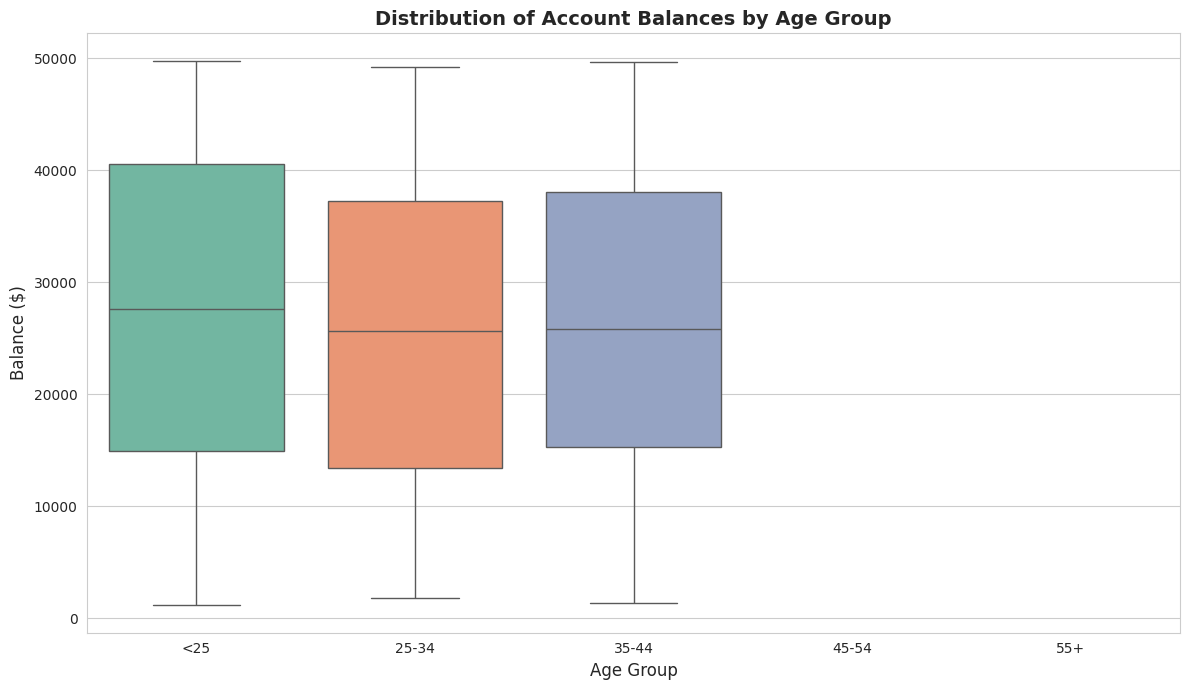

In [61]:
# Get more data for box plot
response = es.search(
    index="bank",
    query={"match_all": {}},
    size=500,
    _source=["age", "balance"]
)

# Extract and prepare data
hits = [hit['_source'] for hit in response['hits']['hits']]
df = pd.DataFrame(hits)

# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 100], 
                         labels=['<25', '25-34', '35-44', '45-54', '55+'])

# Create box plot
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='age_group', y='balance', palette='Set2')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Balance ($)', fontsize=12)
plt.title('Distribution of Account Balances by Age Group', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Summary

In this lesson, you've learned the fundamentals of Elasticsearch:

### Core Concepts
- **Distributed search engine** built on Apache Lucene
- **Document-oriented** storage with JSON format
- **RESTful API** for all operations
- **Real-time** indexing and search

### Key Operations
- **Indexing**: Single documents and bulk operations
- **Searching**: Full-text search, phrase matching, boolean queries
- **Filtering**: Range queries and structured data filtering
- **Aggregations**: Metrics, buckets, and nested aggregations
- **CRUD**: Complete document lifecycle management

### Query DSL
- `match` for full-text search with analysis
- `match_phrase` for exact phrase matching
- `bool` queries with must/should/must_not/filter
- `fuzzy`, `wildcard`, and `multi_match` for flexible searching
- `range` filters for numeric and date ranges

### Best Practices
✓ Use bulk API for indexing large datasets  
✓ Use filters (not queries) for exact matches  
✓ Avoid leading wildcards in wildcard queries  
✓ Set appropriate `size` limits for query results  
✓ Leverage aggregations for real-time analytics  

### What's Next?
This lesson covered Elasticsearch as a standalone search engine. In future lessons, we'll explore:
- **Kibana**: Visualization and exploration UI
- **Integration patterns**: Embedding Elasticsearch in applications
- **Index management**: Mappings, settings, and optimization
- **Production considerations**: Clustering, scaling, and monitoring

### Box Plot: Balance by Age Groups

In [ ]:
# Get sample data for scatter plot
response = es.search(
    index="bank",
    query={"match_all": {}},
    size=200,
    _source=["age", "balance", "gender"]
)

# Extract data
hits = [hit['_source'] for hit in response['hits']['hits']]
df = pd.DataFrame(hits)

# Create scatter plot with color by gender
plt.figure(figsize=(12, 7))
colors = {'M': 'blue', 'F': 'red'}
for gender in df['gender'].unique():
    subset = df[df['gender'] == gender]
    plt.scatter(subset['age'], subset['balance'], 
               c=colors[gender], label=f'Gender {gender}', 
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Balance ($)', fontsize=12)
plt.title('Account Balance vs Age by Gender', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Scatter Plot: Age vs Balance

In [ ]:
# Get average balance by state
response = es.search(
    index="bank",
    size=0,
    aggs={
        "by_state": {
            "terms": {
                "field": "state.keyword",
                "size": 15,
                "order": {
                    "avg_balance": "desc"
                }
            },
            "aggs": {
                "avg_balance": {
                    "avg": {
                        "field": "balance"
                    }
                }
            }
        }
    }
)

# Extract data
buckets = response['aggregations']['by_state']['buckets']
states = [b['key'] for b in buckets]
avg_balances = [b['avg_balance']['value'] for b in buckets]

# Create horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(states, avg_balances, color='mediumseagreen', edgecolor='black')
plt.xlabel('Average Balance ($)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.title('Average Account Balance by State (Top 15)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top
plt.tight_layout()
plt.show()

### Average Balance by State

In [ ]:
# Get gender distribution
response = es.search(
    index="bank",
    size=0,
    aggs={
        "by_gender": {
            "terms": {
                "field": "gender.keyword"
            }
        }
    }
)

# Extract data
buckets = response['aggregations']['by_gender']['buckets']
genders = [b['key'] for b in buckets]
counts = [b['doc_count'] for b in buckets]

# Create pie chart
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)
plt.pie(counts, labels=genders, autopct='%1.1f%%', startangle=90, 
        colors=colors, explode=explode, shadow=True)
plt.title('Gender Distribution of Account Holders', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Pie Chart: Gender Distribution

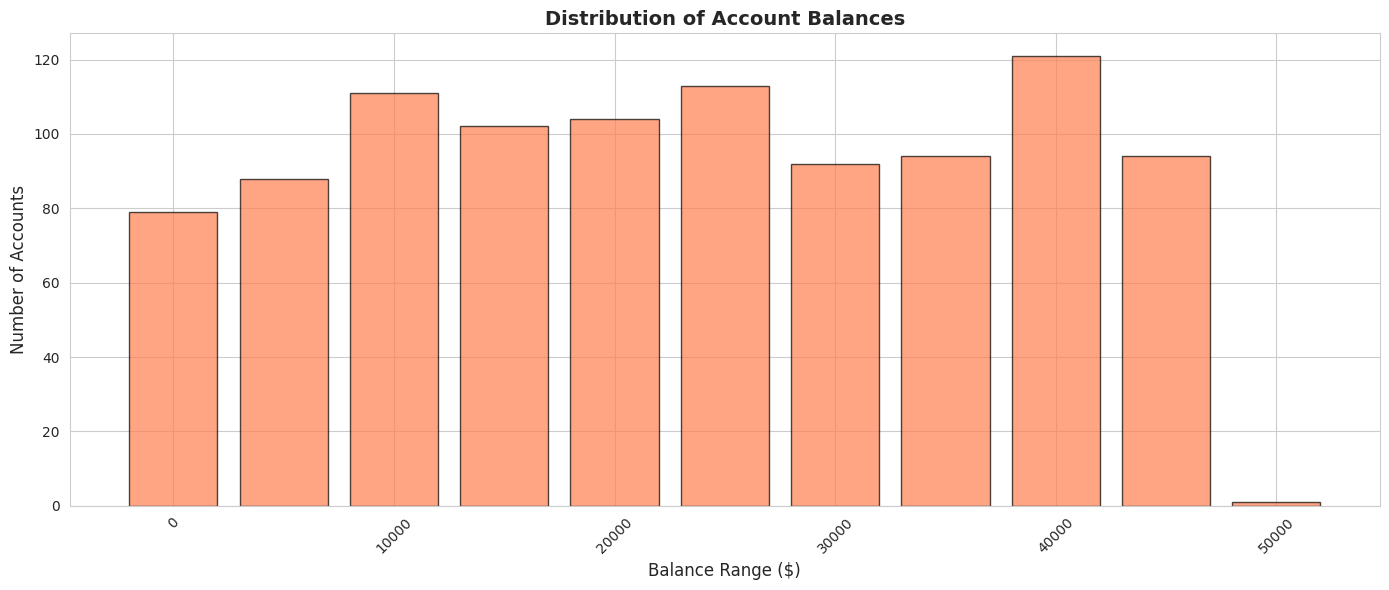

In [60]:
# Get balance histogram
response = es.search(
    index="bank",
    size=0,
    aggs={
        "balance_histogram": {
            "histogram": {
                "field": "balance",
                "interval": 5000
            }
        }
    }
)

# Extract data
buckets = response['aggregations']['balance_histogram']['buckets']
balance_ranges = [b['key'] for b in buckets]
counts = [b['doc_count'] for b in buckets]

# Create histogram
plt.figure(figsize=(14, 6))
plt.bar(balance_ranges, counts, width=4000, color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Balance Range ($)', fontsize=12)
plt.ylabel('Number of Accounts', fontsize=12)
plt.title('Distribution of Account Balances', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Histogram: Balance Distribution

In [ ]:
# Get account counts by state
response = es.search(
    index="bank",
    size=0,
    aggs={
        "by_state": {
            "terms": {
                "field": "state.keyword",
                "size": 10
            }
        }
    }
)

# Extract data for plotting
buckets = response['aggregations']['by_state']['buckets']
states = [b['key'] for b in buckets]
counts = [b['doc_count'] for b in buckets]

# Create bar chart
plt.figure(figsize=(12, 6))
plt.bar(states, counts, color='steelblue', edgecolor='black')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Accounts', fontsize=12)
plt.title('Top 10 States by Account Count', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Bar Chart: Accounts by State

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import urllib3

# Disable SSL warnings for cleaner output
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [58]:
!pip install matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.2/113.2 kB 1.2 MB/s eta 0:00:001m914.7 kB/s eta 0:00:01
  Using cached pillow-12.0.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 21.5 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.4 MB/s eta 0:00:0031m58.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.6 MB/s eta 0:00:00m eta 0:00:01
Using cached pillow-12.0.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (7.0 MB)
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)


### Install Visualization Libraries

## Visualizing Search and Aggregation Results

Elasticsearch aggregations are powerful, but visualizations make patterns and insights much easier to spot. Let's use matplotlib and seaborn to create charts from our aggregation data.

**Note**: In production systems, you might use dedicated visualization tools, but Python libraries are perfect for exploratory analysis and custom reporting.